<a href="https://colab.research.google.com/github/unhappyenergy/Assignments/blob/main/week6_Lakshya_Choudhary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Import Dataset

In [3]:
import zipfile

zip_path = "/content/dataset_week6.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/mnist_data")

print("Dataset extracted!")

print(os.listdir("/content/mnist_data"))


Dataset extracted!
['mnist_png']


# Transform

In [5]:
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

train_path = "/content/mnist_data/mnist_png/training"
test_path = "/content/mnist_data/mnist_png/testing"

train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=test_path,
    transform=transform
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

Training images: 60000
Testing images: 10000


# Load dataset

In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# Data Visualization

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


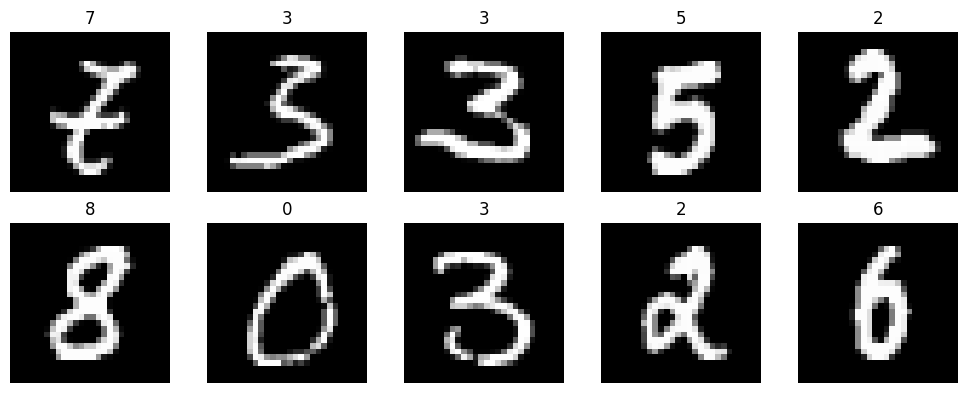

In [7]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(labels[i].item())
    plt.axis("off")

plt.tight_layout()
plt.show()

# Adding Noise

In [8]:
def add_noise(images, noise_factor=0.4):
    noise = torch.randn_like(images) * noise_factor
    noisy_images = images + noise
    noisy_images = torch.clamp(noisy_images, 0., 1.)

    return noisy_images

 - After adding noise

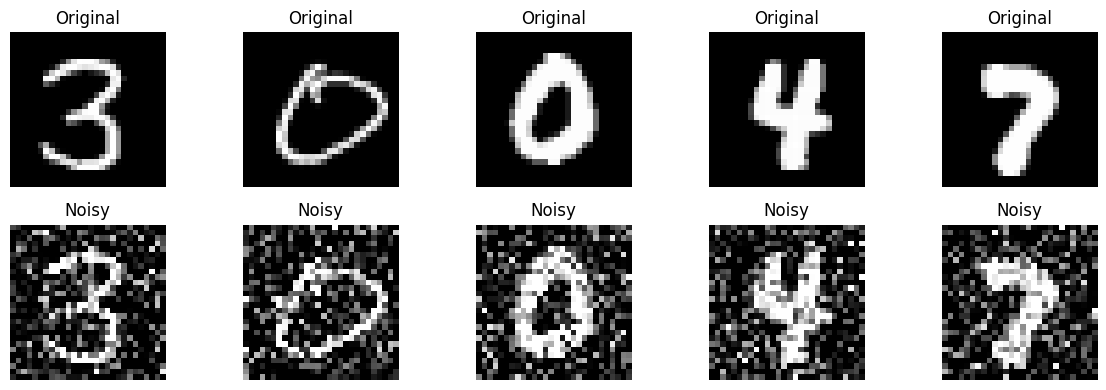

In [9]:
images, labels = next(iter(train_loader))

noisy_images = add_noise(images)

plt.figure(figsize=(12, 4))

for i in range(5):
    # Original image
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy image
    plt.subplot(2, 5, i + 6)
    plt.imshow(noisy_images[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Autoencoder Architecture

In [11]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 4, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 16, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Training Model

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)

print(model)
print("\nUsing device:", device)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)

Using device: cuda


- Defining our Loss Function
- Optimizer

In [14]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## Training Loop

In [15]:
epochs = 10
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        # Add noise to the input images
        noisy_images = add_noise(images)

        outputs = model(noisy_images)

        # Loss between reconstructed and original images
        loss = criterion(outputs, images)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/10, Loss: 0.0570
Epoch 2/10, Loss: 0.0240
Epoch 3/10, Loss: 0.0223
Epoch 4/10, Loss: 0.0216
Epoch 5/10, Loss: 0.0211
Epoch 6/10, Loss: 0.0206
Epoch 7/10, Loss: 0.0203
Epoch 8/10, Loss: 0.0201
Epoch 9/10, Loss: 0.0199
Epoch 10/10, Loss: 0.0198


### Checking Training Loss

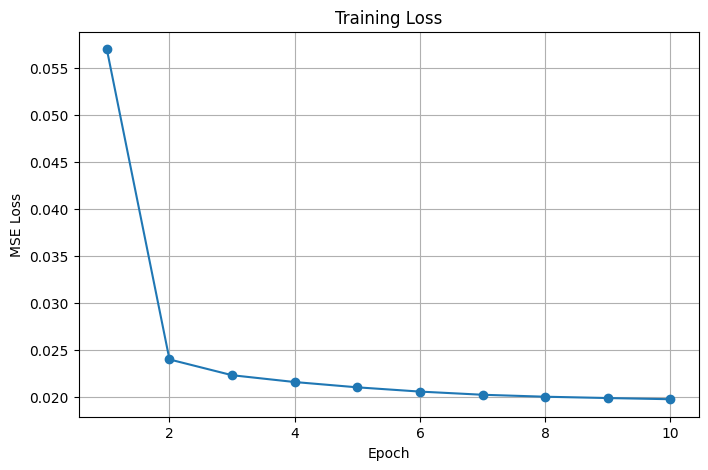

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, epochs + 1), train_losses, marker='o')

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.grid()
plt.show()

In [17]:
model.eval()

test_loss = 0.0

with torch.no_grad():

    for images, _ in test_loader:

        images = images.to(device)

        noisy_images = add_noise(images)

        outputs = model(noisy_images)

        loss = criterion(outputs, images)

        test_loss += loss.item()

test_loss = test_loss / len(test_loader)

print("Test Loss:", round(test_loss, 4))

Test Loss: 0.0195


## Test on Noisy Images

In [22]:
model.eval()

selected_images = []
selected_labels = []

for digit in range(10):
    for image, label in test_dataset:
        if label == digit:
            selected_images.append(image)
            selected_labels.append(label)
            break

test_images = torch.stack(selected_images).to(device)

# Add noise
noisy_test_images = add_noise(test_images)

# Denoise
with torch.no_grad():
    denoised_images = model(noisy_test_images)

print("Selected digits:", selected_labels)

Selected digits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [19]:
print("Original shape :", test_images.shape)
print("Noisy shape    :", noisy_test_images.shape)
print("Denoised shape :", denoised_images.shape)

Original shape : torch.Size([64, 1, 28, 28])
Noisy shape    : torch.Size([64, 1, 28, 28])
Denoised shape : torch.Size([64, 1, 28, 28])


# Comparison Plot

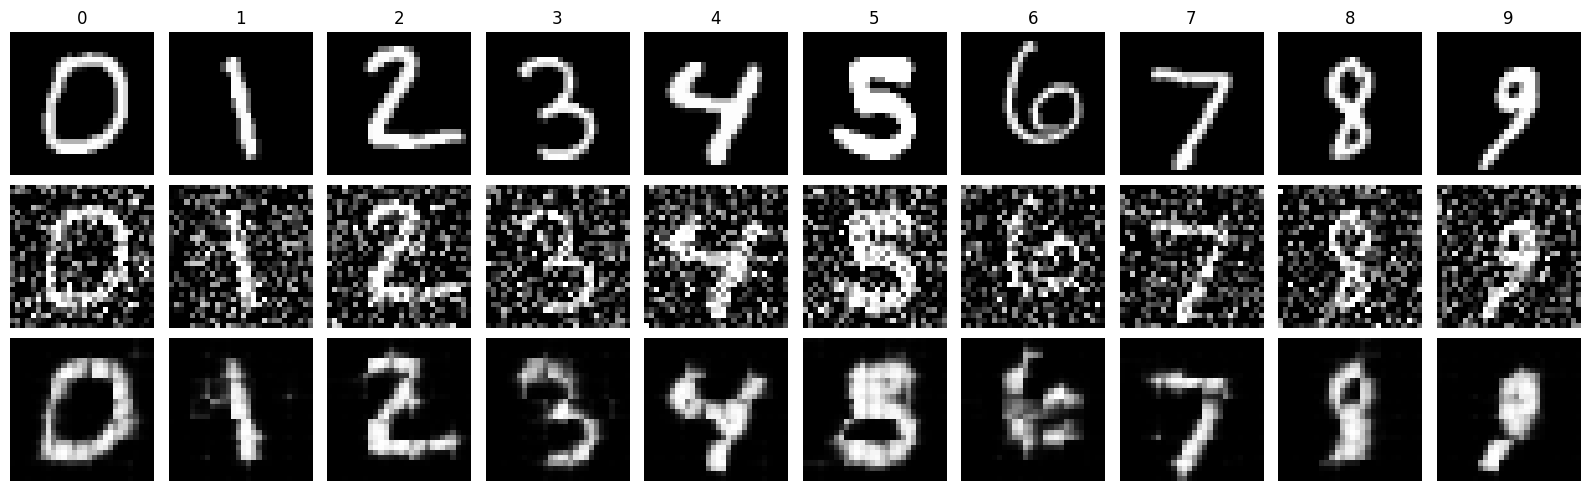

In [23]:
num_images = 10

plt.figure(figsize=(16, 5))

for i in range(num_images):

    # Original
    plt.subplot(3, num_images, i + 1)
    plt.imshow(test_images[i].cpu().squeeze(), cmap="gray")
    plt.title(str(selected_labels[i]))
    plt.axis("off")

    # Noisy
    plt.subplot(3, num_images, i + 1 + num_images)
    plt.imshow(noisy_test_images[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")

    # Denoised
    plt.subplot(3, num_images, i + 1 + 2 * num_images)
    plt.imshow(denoised_images[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Conclusion
- Built a convolutional autoencoder to remove noise from MNIST images.

- Trained the model using Adam optimizer and MSE loss.

- The model successfully reduced noise and reconstructed recognizable digits.

- Some reconstructed images were slightly blurry due to information loss during compression.

In [24]:
torch.save(model.state_dict(), "mnist_denoising_autoencoder.pth")
print("Model saved successfully")

Model saved successfully
